In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df= pd.read_csv("smartcart_customers.csv")

In [4]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [5]:
df.shape

(2240, 22)

In [8]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [10]:
# data preprocessing

# 1. handle missing values

df["Income"] = df["Income"].fillna(df["Income"].median())

In [11]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [12]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [15]:
# feature engineering

#age

df["Age"] = 2026-df["Year_Birth"]

In [26]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [27]:
#customer joining date

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [25]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [28]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='object')

In [29]:
#spending

df["Total_Spending"] = df["MntWines"] +  df["MntFruits"] +  df["MntMeatProducts"] +  df["MntFishProducts"] +  df["MntSweetProducts"]+  df["MntGoldProds"]

In [30]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days',
       'Total_Spending'],
      dtype='object')

In [31]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,8,10,4,7,0,1,69,663,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,1,1,2,5,0,0,72,113,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,1,8,2,10,4,0,0,61,312,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,2,0,4,6,0,0,42,139,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,5,3,6,5,0,0,45,161,422


In [33]:
#Children

df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [41]:
#Education 
df["Education"].value_counts()

df["Education"] = df["Marital_Status"].replace({
    "Basic": "Undergraduate", "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate", "PHD":"Postgraduate"
})

#undergrad, graduate, postgrad

In [42]:
df["Education"].value_counts()

Education
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [40]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [39]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [79]:
# Marital Status

df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Undergraduate", "Together": "Undergraduate",
    "Single": "Alone", "Divorced":"Alone",
    "Window": "Alone", "Absurd":"Alone","YOLO":"Alone"
})

In [81]:
df["Living_With"].value_counts()

Living_With
Undergraduate    1444
Alone             719
Widow              77
Name: count, dtype: int64

In [48]:
# Drop Columns
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,5524,1957,Single,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Single,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Together,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Undergraduate
3,6182,1984,Together,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Undergraduate
4,5324,1981,Married,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Undergraduate


In [60]:
cols = ["ID", "Year_Birth", "Marital_Status","Kidhome" , "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

cols_to_drop = cols+spending_cols

df_cleaned = df.drop(columns = cols_to_drop)

In [61]:
df_cleaned.shape

(2240, 15)

In [62]:
df.shape

(2240, 27)

In [63]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Single,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Single,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Together,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Undergraduate
3,Together,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Undergraduate
4,Married,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Undergraduate


In [65]:
cols = ["ID","Year_Birth","Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols=["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

In [66]:
df_cleaned.shape

(2240, 15)

In [67]:
df.shape

(2240, 27)

In [68]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Single,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Single,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Together,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Undergraduate
3,Together,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Undergraduate
4,Married,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Undergraduate


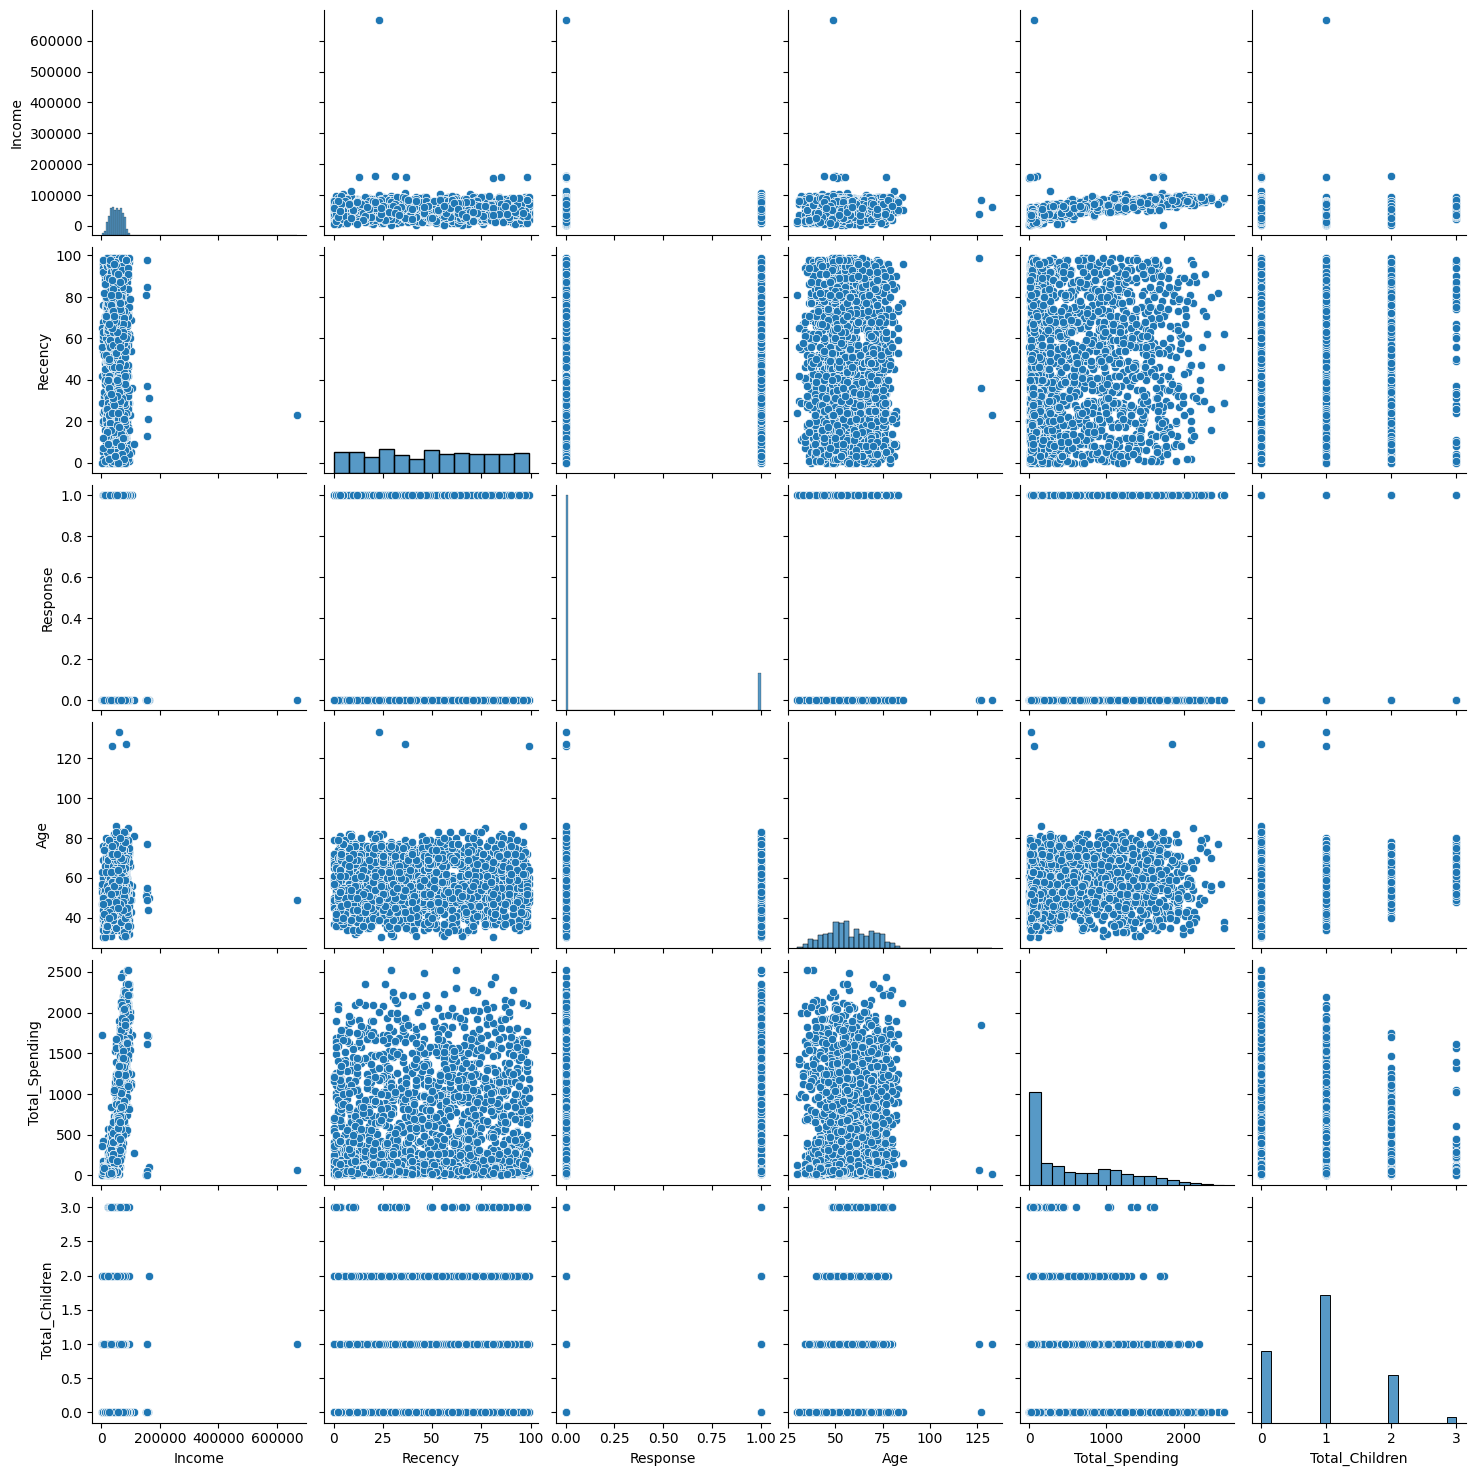

In [69]:
#Outliers

cols = ["Income","Recency","Response", "Age", "Total_Spending","Total_Children"]

#relative plot for some features - pair plots
sns.pairplot(df_cleaned[cols])

In [70]:
#remove outliers
print("data size with outliers",len(df_cleaned))

df_cleaned = df_cleaned [ (df_cleaned["Age"]<90)]
df_cleaned = df_cleaned[(df_cleaned["Income"]<600_000)]

print("data size with outliers",len(df_cleaned))

data size with outliers 2240
data size with outliers 2236


In [71]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

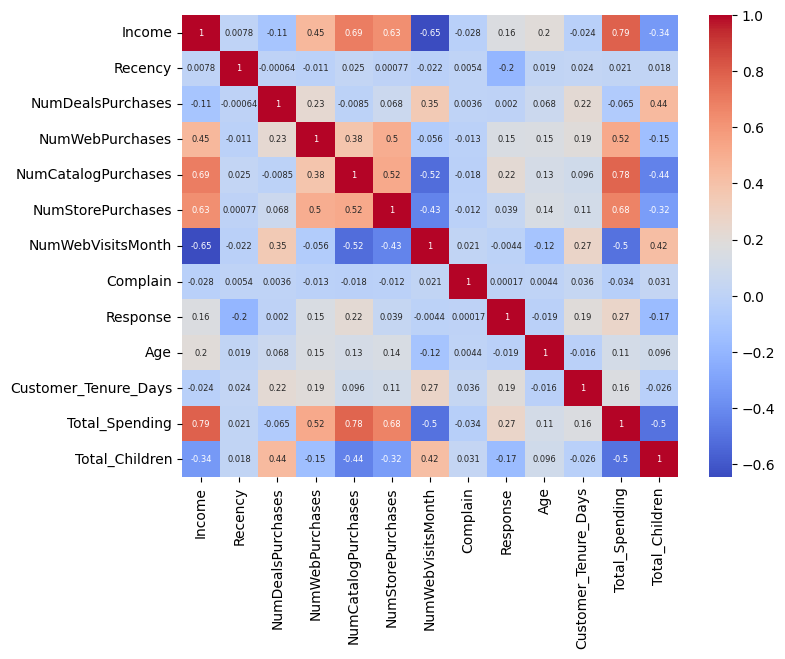

In [74]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

In [75]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Single,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Single,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Together,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Undergraduate
3,Together,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Undergraduate
4,Married,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Undergraduate


In [76]:
df_cleaned.shape

(2236, 15)

In [77]:
#Encoding

from sklearn.preprocessing import OneHotEncoder

In [84]:
ohe = OneHotEncoder()

cat_cols = ["Education","Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [87]:
enc_df = pd.DataFrame(enc_cols.toarray(),columns = ohe.get_feature_names_out(cat_cols),index = df_cleaned.index)

In [89]:
enc_df.head()

,Education_Absurd,Education_Alone,Education_Divorced,Education_Married,Education_Single,Education_Together,Education_Widow,Education_YOLO,Living_With_Alone,Living_With_Undergraduate,Living_With_Widow
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [92]:
df_encoded = pd.concat([df_cleaned.drop(columns = cat_cols),enc_df], axis=1)

In [93]:
df_encoded.shape

(2236, 24)

In [95]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,...,Education_Alone,Education_Divorced,Education_Married,Education_Single,Education_Together,Education_Widow,Education_YOLO,Living_With_Alone,Living_With_Undergraduate,Living_With_Widow
0,58138.0,58,3,8,10,4,7,0,1,69,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,26646.0,26,2,2,0,4,6,0,0,42,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,58293.0,94,5,5,3,6,5,0,0,45,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [96]:
#Scaling
from sklearn.preprocessing import StandardScaler

In [97]:
x = df_encoded

In [99]:
scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

In [100]:
x_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ...,  1.45552379,
        -1.3476353 , -0.18885089],
       [-0.262003  , -0.38397129, -0.16869955, ...,  1.45552379,
        -1.3476353 , -0.18885089],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.68703789,
         0.74204052, -0.18885089],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ...,  1.45552379,
        -1.3476353 , -0.18885089],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.68703789,
         0.74204052, -0.18885089],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.68703789,
         0.74204052, -0.18885089]], shape=(2236, 24))

In [101]:
#Visuaize

x_scaled.shape

(2236, 24)

In [102]:
#2D

from sklearn.decomposition import PCA

In [145]:
pca = PCA(n_components = 3)

x_pca = pca.fit_transform(x_scaled)

Text(0.5, 0.92, '3D projection')

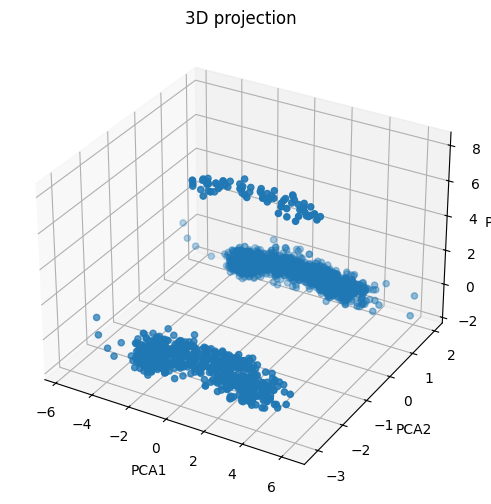

In [147]:
#Plot
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D projection")

In [109]:
pca.explained_variance_ratio_

array([0.17334761, 0.13718705])

In [115]:
#ANALYZE K VALUE

# 1. Elbow method

from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k, random_state=42)
    kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)
    

In [119]:
knee = KneeLocator(range(1,11),wcss, curve="convex",direction="decreasing")
optimal_k = knee.elbow

In [120]:
print("best k = ",optimal_k)

best k =  4


Text(0, 0.5, 'WCSS')

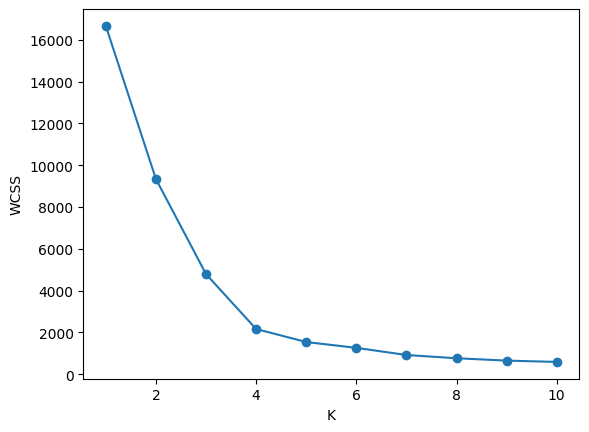

In [121]:
#plot

plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")

Text(0, 0.5, 'Silhouette score')

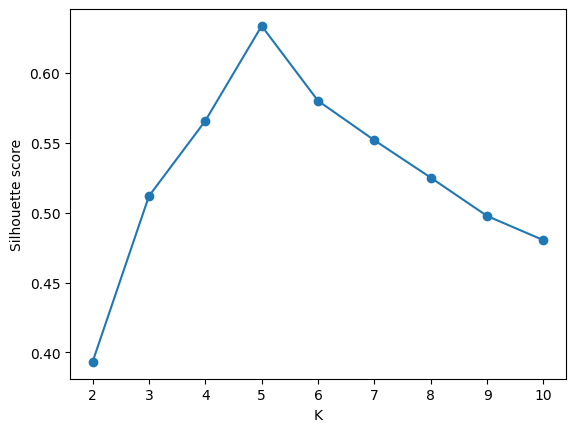

In [148]:
## 2. silhoutte score

from sklearn.metrics import silhouette_score

scores=[]

for k in range(2,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    labels = kmeans.fit_predict(x_pca)
    score = silhouette_score(x_pca,labels)
    scores.append(score)

#plot
plt.plot(range(2,11),scores,marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette score")

Text(0, 0.5, 'SS')

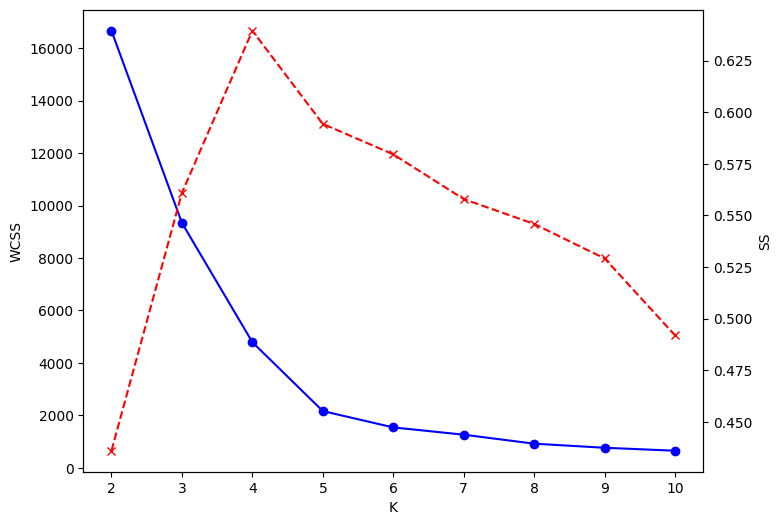

In [133]:
#combined plot

k_range = range(2,11)

fig, ax1 = plt.subplots(figsize = (8,6))

ax1.plot(k_range, wcss[:len(k_range)], marker='o', color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")
ax2 = ax1.twinx()
ax2.plot(k_range, scores[: len(k_range)],marker='x', color="red", linestyle="--")
ax2.set_ylabel("SS")

In [135]:
#clustering
#KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(x_pca)

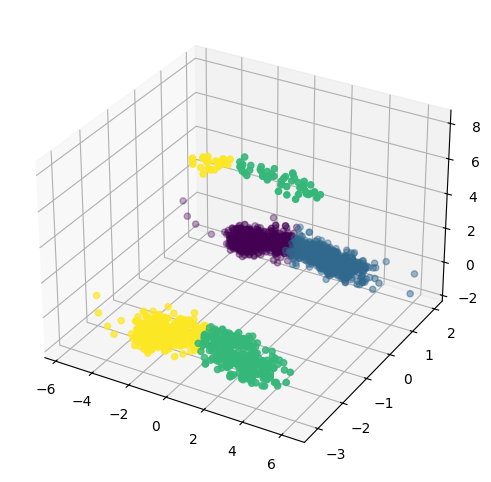

In [149]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2],c = labels_kmeans)

In [142]:
#Agglomerative clustering
from sklearn.cluster import AgglomerativeClustering

In [143]:
agg_clf = AgglomerativeClustering(n_clusters = 4, linkage="ward")
labels_agg =  agg_clf.fit_predict(x_pca)

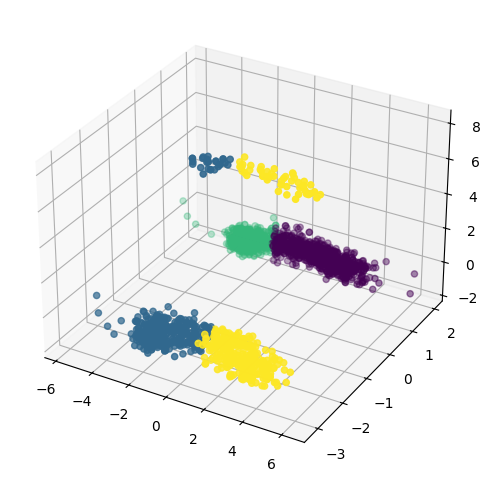

In [150]:
fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111, projection = "3d")
ax.scatter(x_pca[:,0], x_pca[:,1],x_pca[:,2], c= labels_agg)

In [172]:
#Characterstics of clusters
x["cluster"] = labels_agg

In [152]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With,labels
0,Single,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone,3
1,Single,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone,1
2,Together,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Undergraduate,0
3,Together,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Undergraduate,2
4,Married,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Undergraduate,0


<Axes: xlabel='cluster', ylabel='count'>

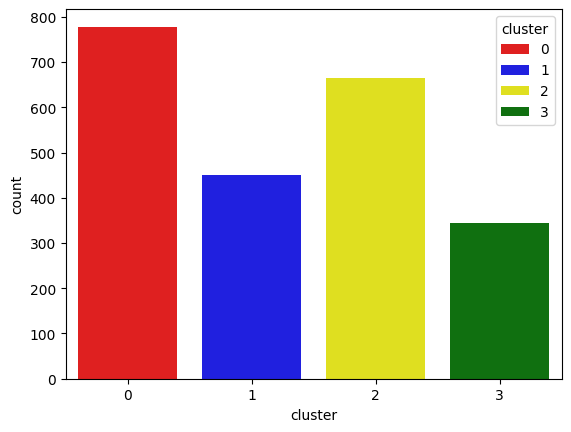

In [166]:
pal = ["red","blue","yellow","green"]
sns.countplot(x=df_cleaned["cluster"], palette=pal ,hue=df_cleaned["cluster"])


<Axes: xlabel='Total_Spending', ylabel='Income'>

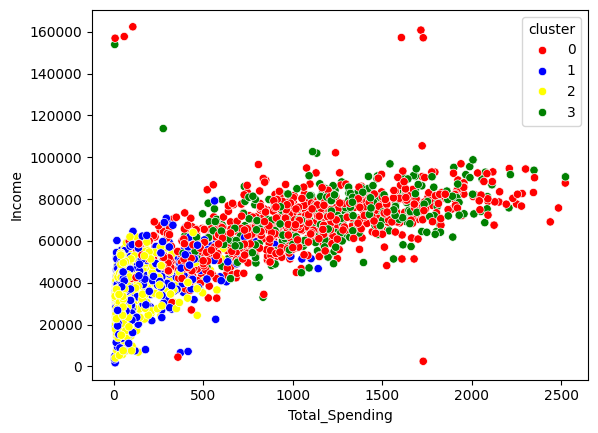

In [169]:
#income and spending patterns

sns.scatterplot(x=df_cleaned["Total_Spending"],y=df_cleaned["Income"],hue=df_cleaned["cluster"], palette = pal)

In [173]:
#Cluster summary

cluster_summary = x.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        67030.387532  48.726221           2.407455         5.619537   
1        37633.066667  48.237778           2.520000         2.811111   
2        34122.740211  49.406627           2.314759         2.289157   
3        71000.069767  50.587209           1.909884         5.764535   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   4.460154           7.971722           4.147815  0.007712   
1                   0.864444           3.720000           6.520000  0.011111   
2                   0.516566           3.272590           6.704819  0.010542   
3                   5.095930           8.459302           3.720930  0.005814   

         Response        Age  ...  Education_Alone  Education_Divorced  \
cluster     